# Machine Learning for EEG signals

In this notebook, we explore classical machine learning methods for classifying electroencephalography (EEG) signals of **eyes open** and **eyes closed*, analyzed using channels **O1**, **O2**.

**Data:** PhysioNet EEG Motor Movement/Imagery Dataset (EEGMMIDB): https://www.physionet.org/content/eegmmidb/1.0.0/

- Run mapping:

        - 1 = baseline eyes open
        - 2 = baseline eyes closed
        - 3, 7, 11 = executed left/right hand
        - 4, 8, 12 = imagined left/right hand
        - 5, 9, 13 = executed hands/feet
        - 6, 10, 14 = imagined hands/feet

- Alternative site (same dataset): https://moabb.neurotechx.com/docs/generated/moabb.datasets.PhysionetMI.html

## 1. Exploratory Data Analysis

In [15]:
import pandas as pd
from mne.io import read_raw_edf
from mne.datasets import eegbci
from tqdm import tqdm

N_SUBJECTS = 109
subjects = range(1, N_SUBJECTS + 1)

run_types = {
    1: "Baseline (Eyes open)",
    2: "Baseline (Eyes closed)",
}

RUNS = [1, 2]

print(f"Total number of subjects: {N_SUBJECTS}")
print(f"Runs: {RUNS} (Eyes Open / Eyes Closed)")

summary = []

for subject in tqdm(subjects, desc="Subjects"):
    files = eegbci.load_data(subject, runs=RUNS)

    for file, run in zip(files, RUNS):
        raw = read_raw_edf(file, preload=False)

        summary.append({
            "Subject": subject,
            "Run": run,
            "Condition": run_types[run],
            "Duration [s]": round(raw.times[-1], 1),
            "Channels": raw.info["nchan"],
            "Sampling freq. [Hz]": raw.info["sfreq"],
            "Samples": len(raw.times),
        })

summary = pd.DataFrame(summary)



Total number of subjects: 109
Runs: [1, 2] (Eyes Open / Eyes Closed)


Subjects:   0%|          | 0/109 [00:00<?, ?it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R02.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R02.edf...
Setting channel info structure...
Creating raw.info structure...


Subjects:   2%|▏         | 2/109 [00:00<00:10, 10.49it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S003\S003R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S003\S003R02.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S004\S004R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S004\S004R02.edf...
Setting channel info structure...
Creating raw.info structure...


...

Subjects:  96%|█████████▋| 105/109 [00:09<00:00, 10.86it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S106\S106R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S106\S106R02.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S107\S107R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S107\S107R02.edf...
Setting channel info structure...
Creating raw.info structure...


Subjects:  98%|█████████▊| 107/109 [00:10<00:00, 10.81it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S108\S108R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S108\S108R02.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S109\S109R01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S109\S109R02.edf...
Setting channel info structure...
Creating raw.info structure...


Subjects: 100%|██████████| 109/109 [00:10<00:00, 10.63it/s]


### 1.1 General summary & statistics

In [16]:
summary.info()
summary

<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Subject              218 non-null    int64  
 1   Run                  218 non-null    int64  
 2   Condition            218 non-null    str    
 3   Duration [s]         218 non-null    float64
 4   Channels             218 non-null    int64  
 5   Sampling freq. [Hz]  218 non-null    float64
 6   Samples              218 non-null    int64  
dtypes: float64(2), int64(4), str(1)
memory usage: 12.1 KB


,Subject,Run,Condition,Duration [s],Channels,Sampling freq. [Hz],Samples
0,1,1,Baseline (Eyes open),61.0,64,160.0,9760
1,1,2,Baseline (Eyes closed),61.0,64,160.0,9760
2,2,1,Baseline (Eyes open),61.0,64,160.0,9760
3,2,2,Baseline (Eyes closed),61.0,64,160.0,9760
4,3,1,Baseline (Eyes open),61.0,64,160.0,9760
...,...,...,...,...,...,...,...
213,107,2,Baseline (Eyes closed),61.0,64,160.0,9760
214,108,1,Baseline (Eyes open),61.0,64,160.0,9760
215,108,2,Baseline (Eyes closed),61.0,64,160.0,9760
216,109,1,Baseline (Eyes open),60.0,64,160.0,9600


In [17]:
summary.describe(include="all")

,Subject,Run,Condition,Duration [s],Channels,Sampling freq. [Hz],Samples
count,218.00000,218.000000,218,218.000000,218.0,218.0,218.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,NaN,Baseline (Eyes open),NaN,NaN,NaN,NaN
freq,NaN,NaN,109,NaN,NaN,NaN,NaN
mean,55.00000,1.500000,NaN,60.977064,64.0,160.0,9756.330275
std,31.53668,0.501151,NaN,0.150043,0.0,0.0,24.006933
min,1.00000,1.000000,NaN,60.000000,64.0,160.0,9600.000000
25%,28.00000,1.000000,NaN,61.000000,64.0,160.0,9760.000000
50%,55.00000,1.500000,NaN,61.000000,64.0,160.0,9760.000000
75%,82.00000,2.000000,NaN,61.000000,64.0,160.0,9760.000000


### 1.2. Unique values, missing values, duplicates

In [18]:
# UNIQUE VALUES
for col in summary.columns:
    print(f"\n{col}")
    print(summary[col].unique())


Subject
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109]

Run
[1 2]

Condition
<StringArray>
['Baseline (Eyes open)', 'Baseline (Eyes closed)']
Length: 2, dtype: str

Duration [s]
[61. 60.]

Channels
[64]

Sampling freq. [Hz]
[160.]

Samples
[9760 9600]


In [19]:
# MISSING VALUES
summary.isna().sum()

Subject                0
Run                    0
Condition              0
Duration [s]           0
Channels               0
Sampling freq. [Hz]    0
Samples                0
dtype: int64

In [20]:
# DUPLICATED RECORDINGS
summary.duplicated().sum()

np.int64(0)

### 1.3. Run consistency

In [21]:
summary.groupby("Run").agg({
    "Duration [s]": ["min", "max", "mean", "std"],
    "Channels": ["min", "max"],
    "Sampling freq. [Hz]": ["min", "max"]
})

Duration [s]                            Channels     Sampling freq. [Hz]  \
             min   max       mean       std      min max                 min   
Run                                                                            
1           60.0  61.0  60.963303  0.188886       64  64               160.0   
2           60.0  61.0  60.990826  0.095783       64  64               160.0   

            
       max  
Run         
1    160.0  
2    160.0

## 2. Feature engineering
- epoching + feature extraction for runs 1 and 2, channels O1, O2

### 2.1 Epoching

In [22]:
import numpy as np
import pandas as pd

from tqdm import tqdm

import mne
from mne.io import read_raw_edf
from mne.datasets import eegbci

N_SUBJECTS = 109
SUBJECTS = range(1, N_SUBJECTS + 1)

RUNS = [1, 2]   # Eyes open / Eyes closed

CHANNELS = ["O1", "O2"]

RUN_LABELS = {
    1: ("EO", "Eyes open"),
    2: ("EC", "Eyes closed"),
}

# preprocessing
FMIN = 1.0
FMAX = 40.0

# epoch parameters
EPOCH_LENGTH = 4.0      # seconds
OVERLAP = 0.0           # set to e.g. 2.0 for 50% overlap

epoch_rows = []

for subject in tqdm(SUBJECTS, desc="Epoching subjects"):

    files = eegbci.load_data(subject, runs=RUNS)

    for file, run in zip(files, RUNS):

        raw = read_raw_edf(file, preload=True, verbose=False)

        eegbci.standardize(raw)

        raw.pick(CHANNELS)

        raw.filter(
            l_freq=FMIN,
            h_freq=FMAX,
            fir_design="firwin",
            verbose=False
        )

        # Create fixed-length epochs
        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=EPOCH_LENGTH,
            overlap=OVERLAP,
            preload=True,
            verbose=False,
        )

        sfreq = epochs.info["sfreq"]
        data = epochs.get_data(copy=True) * 1e6   # V -> µV

        label, label_name = RUN_LABELS[run]

        for epoch_idx, epoch_data in enumerate(data):

            row = {
                "subject": subject,
                "run": run,
                "epoch": epoch_idx,
                "label": label,
                "label_name": label_name,
                "sfreq": sfreq,
            }

            for ch_idx, channel in enumerate(CHANNELS):
                row[channel] = epoch_data[ch_idx]

            epoch_rows.append(row)

epochs_df = pd.DataFrame(epoch_rows)

print(epochs_df.shape)
print()
print(epochs_df["label"].value_counts())
print()
epochs_df.head()

Epoching subjects: 100%|██████████| 109/109 [00:11<00:00,  9.66it/s]

(3270, 8)

label
EO    1635
EC    1635
Name: count, dtype: int64



,subject,run,epoch,label,label_name,sfreq,O1,O2
0,1,1,0,EO,Eyes open,160.0,"[1.3552527156068805e-14, -0.4495899452399765, ...","[6.776263578034403e-15, 11.414155339675062, 29..."
1,1,1,1,EO,Eyes open,160.0,"[-16.8293451543515, -7.841964391439181, -16.55...","[-32.078199964396724, -30.989971210718195, -53..."
2,1,1,2,EO,Eyes open,160.0,"[25.464860634210503, 46.873842033350755, 52.56...","[20.662896579081515, 45.73454032781503, 45.905..."
3,1,1,3,EO,Eyes open,160.0,"[-6.56583943794626, 2.880078805699262, 0.96333...","[-56.502935020158425, -41.76948429506554, -41...."
4,1,1,4,EO,Eyes open,160.0,"[23.644907431053227, 20.937379364484002, -6.10...","[-38.81207661417008, -30.58902376298984, -47.0..."


### 2.2 Feature extraction

For each epoch and each channel (**O1**, **O2**), we compute a set of features describing the EEG signal from multiple perspectives.

| Feature category | Features |
|------------------|----------|
| **Time-domain** | Mean, Variance, Standard deviation, Root mean square (RMS), Peak-to-peak amplitude, Skewness, Kurtosis |
| **Frequency-domain** | Delta (1–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz), and Beta (13–30 Hz) absolute band powers, Relative delta/theta/alpha/beta band powers, Dominant frequency |
| **Nonlinear** | Sample entropy, Higuchi fractal dimension, Correlation dimension, Largest Lyapunov exponent |

For nonlinear features based on phase-space reconstruction (correlation dimension and largest Lyapunov exponent), we reuse the embedding parameters determined in the previous notebook (*Nonlinear analysis*).



In [23]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch

import antropy as ant
import nolds

m_eoec = 6

embedding_params_eoec = {
    "long_tau": {
        "O1": {"tau": 31, "m": m_eoec},
        "O2": {"tau": 31, "m": m_eoec},
    },
    "short_tau": {
        "O1": {"tau": 8, "m": m_eoec},
        "O2": {"tau": 8, "m": m_eoec},
    },
}


def bandpower_welch(x, sfreq, band, nperseg=None):
    if nperseg is None:
        nperseg = min(len(x), int(2 * sfreq))

    freqs, psd = welch(x, fs=sfreq, nperseg=nperseg)
    mask = (freqs >= band[0]) & (freqs <= band[1])

    if not np.any(mask):
        return np.nan

    return np.trapezoid(psd[mask], freqs[mask])


def dominant_frequency(x, sfreq, fmin=1.0, fmax=30.0, nperseg=None):
    if nperseg is None:
        nperseg = min(len(x), int(2 * sfreq))

    freqs, psd = welch(x, fs=sfreq, nperseg=nperseg)
    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.nan

    freqs_sel = freqs[mask]
    psd_sel = psd[mask]

    return freqs_sel[np.argmax(psd_sel)]


def extract_channel_features(x, sfreq, channel):
    features = {}

    # Time-domain features
    features["mean"] = np.mean(x)
    features["variance"] = np.var(x)
    features["std"] = np.std(x)
    features["rms"] = np.sqrt(np.mean(x ** 2))
    features["ptp"] = np.ptp(x)
    features["skewness"] = skew(x)
    features["kurtosis"] = kurtosis(x)

    # Frequency-domain features
    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
    }

    abs_powers = {}

    for band_name, band_range in bands.items():
        power = bandpower_welch(x, sfreq, band_range)
        abs_powers[band_name] = power
        features[f"{band_name}_power"] = power

    total_power = bandpower_welch(x, sfreq, (1, 30))

    for band_name, power in abs_powers.items():
        features[f"relative_{band_name}_power"] = (
            power / total_power if total_power > 0 else np.nan
        )

    features["dominant_frequency"] = dominant_frequency(x, sfreq)

    # Especially relevant for eyes open/closed
    features["alpha_beta_ratio"] = (
        abs_powers["alpha"] / abs_powers["beta"]
        if abs_powers["beta"] > 0 else np.nan
    )

    features["alpha_theta_ratio"] = (
        abs_powers["alpha"] / abs_powers["theta"]
        if abs_powers["theta"] > 0 else np.nan
    )

    # Nonlinear features
    features["sample_entropy"] = ant.sample_entropy(x)
    features["higuchi_fd"] = ant.higuchi_fd(x, kmax=8)

    for param_name, param_set in embedding_params_eoec.items():
        params = param_set[channel]
        tau = params["tau"]
        m = params["m"]

        try:
            features[f"correlation_dimension_{param_name}"] = nolds.corr_dim(
                x,
                emb_dim=m,
                lag=tau
            )
        except Exception:
            features[f"correlation_dimension_{param_name}"] = np.nan

        try:
            features[f"lyapunov_exponent_{param_name}"] = nolds.lyap_r(
                x,
                emb_dim=m,
                lag=tau,
                min_tsep=10,
                trajectory_len=20,
                fit="poly"
            )
        except Exception:
            features[f"lyapunov_exponent_{param_name}"] = np.nan

    return features


feature_rows = []

for _, epoch in tqdm(
    epochs_df.iterrows(),
    total=len(epochs_df),
    desc="Extracting EO/EC features"
):

    row = {
        "subject": epoch["subject"],
        "run": epoch["run"],
        "epoch": epoch["epoch"],
        "label": epoch["label"],
        "label_name": epoch["label_name"],
    }

    for channel in CHANNELS:
        x = epoch[channel]
        sfreq = epoch["sfreq"]

        feats = extract_channel_features(
            x=x,
            sfreq=sfreq,
            channel=channel
        )

        for feat_name, feat_value in feats.items():
            row[f"{channel}_{feat_name}"] = feat_value

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

print(features_df.shape)
print(features_df["label"].value_counts())

features_df.to_csv("bci_eyes_open_closed_features_all_subjects.csv", index=False)

features_df.head()

Extracting EO/EC features:   1%|          | 18/3270 [00:02<06:47,  7.98it/s]C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
Extracting EO/EC features:   1%|▏         | 41/3270 [00:05<06:24,  8.40it/s]C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
Extracting EO/EC features:   2%|▏         | 50/3270 [00:06<06:16,  8.56it/s]C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288:

(3270, 53)
label
EO    1635
EC    1635
Name: count, dtype: int64


,subject,run,epoch,label,label_name,O1_mean,O1_variance,O1_std,O1_rms,O1_ptp,...,O2_relative_beta_power,O2_dominant_frequency,O2_alpha_beta_ratio,O2_alpha_theta_ratio,O2_sample_entropy,O2_higuchi_fd,O2_correlation_dimension_long_tau,O2_lyapunov_exponent_long_tau,O2_correlation_dimension_short_tau,O2_lyapunov_exponent_short_tau
0,1,1,0,EO,Eyes open,2.680388,1193.656033,34.549328,34.653146,208.995539,...,0.205277,1.5,0.705778,0.765052,1.019226,1.488476,-1.334428e-15,0.027464,6.378797e-03,0.018925
1,1,1,1,EO,Eyes open,0.106591,1571.390366,39.640766,39.640910,235.689704,...,0.177713,1.5,0.754003,1.012804,1.054084,1.533194,-4.570525e-16,0.030664,4.624425e-03,0.020092
2,1,1,2,EO,Eyes open,-0.743625,1545.198908,39.309018,39.316051,232.776435,...,0.123602,1.5,0.614758,0.640888,0.969965,1.531287,3.885391e-02,0.031315,2.294080e-15,0.016063
3,1,1,3,EO,Eyes open,0.966517,1726.130468,41.546726,41.557967,222.443107,...,0.193097,2.0,0.846124,1.111429,1.103252,1.546908,-2.527125e-15,0.029619,3.824651e-03,0.018078
4,1,1,4,EO,Eyes open,-1.242845,1342.404460,36.638838,36.659912,269.177893,...,0.185799,1.0,0.804087,0.753345,0.946646,1.487206,5.067241e-03,0.025730,6.541602e-03,0.016031


### 2.3. Feature selection
Steps:
1. simple **subject-wise stratified split**
2. **z-score** normalization - since many features are measured on different scales (fit on train)
3. **corelation analysis**
4. **feature selection** using univariate filter methods ANOVA F-test and Mutual Information


#### SUBJECT-WISE STARTIFIED SPLIT

In [26]:
from sklearn.model_selection import GroupShuffleSplit

metadata = ["subject", "run", "epoch", "label", "label_name"]

X = features_df.drop(columns=metadata)
y = features_df["label"]

groups = features_df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print("Train subjects:", features_df.iloc[train_idx]["subject"].nunique())
print("Test subjects :", features_df.iloc[test_idx]["subject"].nunique())

print(
    set(features_df.iloc[train_idx]["subject"])
    & set(features_df.iloc[test_idx]["subject"])
)

Train subjects: 87
Test subjects : 22
set()


#### Z-SCORE NORMALIZATION

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

#### CORRELATION ANALYSIS

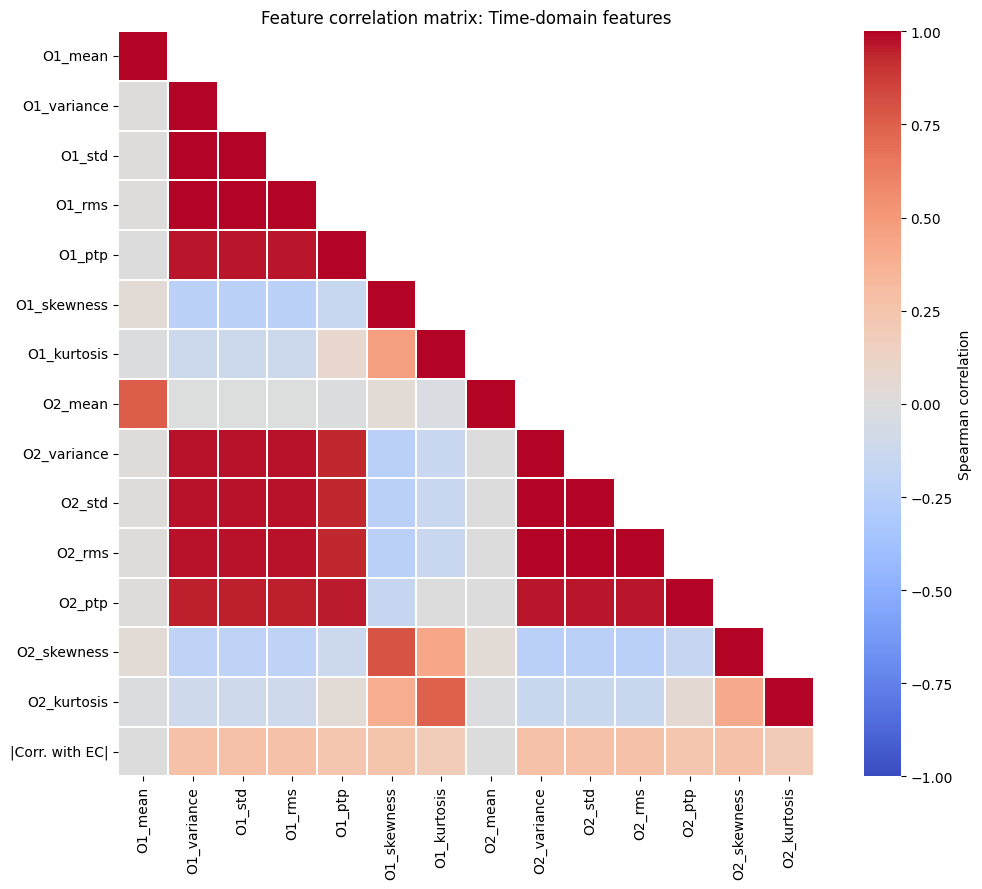

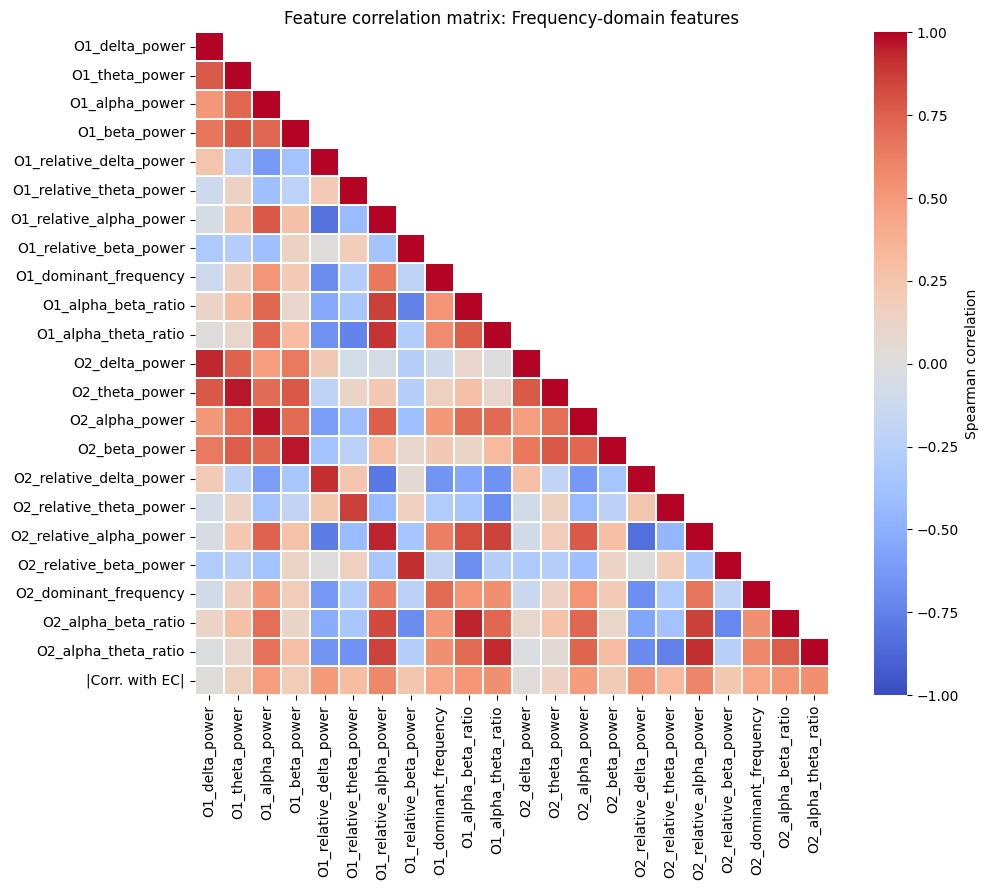

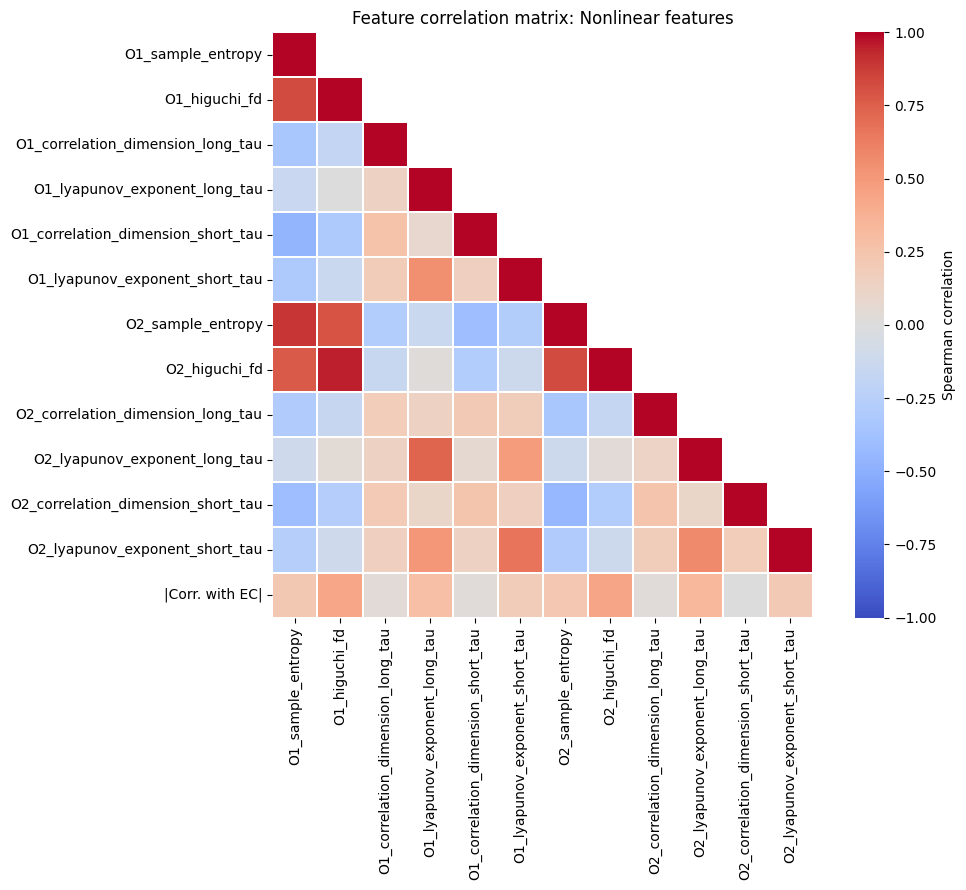

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_corr_matrix(data, y, title, positive_label="EC", figsize=(10, 8)):
    """
    Plot feature correlation matrix with an additional row showing
    the absolute Spearman correlation of each feature with the label.

    For EO/EC:
    EO -> 0
    EC -> 1
    """

    corr = data.corr(method="spearman")

    y_num = (y == positive_label).astype(int)

    label_corr = data.apply(
        lambda x: x.corr(y_num, method="spearman")
    ).abs()

    corr_display = corr.copy()
    corr_display.loc[f"|Corr. with {positive_label}|"] = label_corr

    mask = np.zeros(corr_display.shape, dtype=bool)
    mask[:-1, :] = np.triu(
        np.ones((corr.shape[0], corr.shape[1]), dtype=bool),
        k=1
    )

    plt.figure(figsize=figsize)

    sns.heatmap(
        corr_display,
        mask=mask,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"label": "Spearman correlation"}
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


feature_families = {
    "Time-domain features": [
        "mean", "variance", "std", "rms", "ptp", "skewness", "kurtosis"
    ],

    "Frequency-domain features": [
        "delta_power", "theta_power", "alpha_power", "beta_power",
        "relative_delta_power", "relative_theta_power",
        "relative_alpha_power", "relative_beta_power",
        "dominant_frequency",
        "alpha_beta_ratio", "alpha_theta_ratio"
    ],

    "Nonlinear features": [
        "sample_entropy", "higuchi_fd",
        "correlation_dimension_long_tau", "lyapunov_exponent_long_tau",
        "correlation_dimension_short_tau", "lyapunov_exponent_short_tau"
    ],
}


for family_name, suffixes in feature_families.items():

    family_cols = [
        col for col in X_train.columns
        if any(col.endswith(suffix) for suffix in suffixes)
    ]

    plot_corr_matrix(
        X_train[family_cols],
        y_train,
        title=f"Feature correlation matrix: {family_name}",
        positive_label="EC",
        figsize=(11, 9)
    )

**Observation**:
1. **Time-domain** heatmap - Strong correlations are observed among the amplitude-related features (variance, standard deviation, RMS, and peak-to-peak amplitude), indicating substantial redundancy. Skewness and kurtosis form a separate group, while mean amplitude is largely independent. Correlations with the eyes-open/eyes-closed label are generally modest, suggesting that time-domain features alone provide limited discriminative power.

2. **Frequency-domain** heatmap - Frequency-domain features show moderate to strong correlations, particularly among absolute band powers and between alpha-related measures. The strongest associations with the eyes-open/eyes-closed label are observed for alpha power and the alpha-based ratios, reflecting the characteristic increase in occipital alpha activity during the eyes-closed condition. Despite some redundancy, these features provide substantially greater discriminative information than the time-domain features.

3. **Nonlinear heatmap** - Nonlinear features exhibit lower redundancy than the time- and frequency-domain features, indicating that they capture complementary aspects of signal dynamics. Moderate correlations are observed between related complexity measures, while correlations with the eyes-open/eyes-closed label are generally moderate, suggesting that nonlinear features provide useful but secondary discriminative information compared with frequency-domain features.

#### FEATURE SELECTION METHODS
- ANOVA-F, Mutual Information

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif

anova = SelectKBest(
    score_func=f_classif,
    k=15
)

anova.fit(X_train, y_train)

anova_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "ANOVA score": anova.scores_
}).sort_values("ANOVA score", ascending=False)

anova_scores.head(20)


,Feature,ANOVA score
37,O2_relative_alpha_power,1284.236714
13,O1_relative_alpha_power,1228.327231
39,O2_dominant_frequency,871.050868
35,O2_relative_delta_power,831.190217
15,O1_dominant_frequency,822.212341
11,O1_relative_delta_power,718.119922
43,O2_higuchi_fd,628.664332
19,O1_higuchi_fd,624.948601
17,O1_alpha_theta_ratio,531.291056
41,O2_alpha_theta_ratio,526.332949


In [31]:
from sklearn.feature_selection import mutual_info_classif

mi = SelectKBest(
    score_func=mutual_info_classif,
    k=15
)

mi.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "MI score": mi.scores_
}).sort_values("MI score", ascending=False)

mi_scores.head(20)

,Feature,MI score
37,O2_relative_alpha_power,0.213523
13,O1_relative_alpha_power,0.190113
17,O1_alpha_theta_ratio,0.176500
41,O2_alpha_theta_ratio,0.167128
33,O2_alpha_power,0.159159
39,O2_dominant_frequency,0.157717
16,O1_alpha_beta_ratio,0.153975
9,O1_alpha_power,0.153406
35,O2_relative_delta_power,0.153175
40,O2_alpha_beta_ratio,0.152830


In [32]:
#COMPARISON (average rank)

anova_scores["ANOVA rank"] = anova_scores["ANOVA score"].rank(ascending=False)
mi_scores["MI rank"] = mi_scores["MI score"].rank(ascending=False)

ranking = (
    anova_scores[["Feature", "ANOVA rank"]]
    .merge(
        mi_scores[["Feature", "MI rank"]],
        on="Feature"
    )
)

ranking["Average rank"] = (
    ranking["ANOVA rank"] +
    ranking["MI rank"]
) / 2

ranking = ranking.sort_values("Average rank")

ranking

,Feature,ANOVA rank,MI rank,Average rank
0,O2_relative_alpha_power,1.0,1.0,1.0
1,O1_relative_alpha_power,2.0,2.0,2.0
2,O2_dominant_frequency,3.0,6.0,4.5
8,O1_alpha_theta_ratio,9.0,3.0,6.0
3,O2_relative_delta_power,4.0,9.0,6.5
9,O2_alpha_theta_ratio,10.0,4.0,7.0
4,O1_dominant_frequency,5.0,12.0,8.5
5,O1_relative_delta_power,6.0,11.0,8.5
10,O1_alpha_beta_ratio,11.0,7.0,9.0
13,O2_alpha_power,14.0,5.0,9.5


***Observation.** Both ANOVA and mutual information identified **O1/O2 relative alpha power** as the two most informative features. Beyond these, the rankings differed slightly: ANOVA favored dominant frequency, relative delta power, and Higuchi fractal dimension, whereas mutual information assigned higher importance to alpha-based power ratios and absolute alpha power.

## 3. Classification

Models used:

1. **Decision Tree** (directly interpretable)

2. **RIPPER** (ruleset, directly interpretable)

3. **XGBoost** (ensemble, not directly interpretable)

Evaluation using **subject-wise 5-fold CV**

### 3.1. Decision Tree

#### **Version A** - using just top 2 features


Accuracy : 0.771
Precision: 0.797
Recall   : 0.728
F1-score : 0.761

Classification report
              precision    recall  f1-score   support

          EC       0.80      0.73      0.76      1635
          EO       0.75      0.81      0.78      1635

    accuracy                           0.77      3270
   macro avg       0.77      0.77      0.77      3270
weighted avg       0.77      0.77      0.77      3270



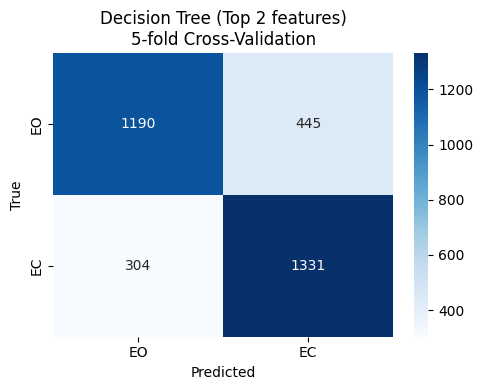

In [76]:
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.base import clone
import numpy as np

selected_features = [
    "O2_relative_alpha_power",
    "O1_relative_alpha_power",
]

X_sel = features_df[selected_features]
y = features_df["label"]
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

y_pred = np.empty(len(y), dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_sel, y, groups), start=1):
    model = clone(base_model)

    model.fit(X_sel.iloc[train_idx], y.iloc[train_idx])
    y_pred[test_idx] = model.predict(X_sel.iloc[test_idx])



# Evaluation
print(f"Accuracy : {accuracy_score(y, y_pred):.3f}")
print(f"Precision: {precision_score(y, y_pred, pos_label='EC'):.3f}")
print(f"Recall   : {recall_score(y, y_pred, pos_label='EC'):.3f}")
print(f"F1-score : {f1_score(y, y_pred, pos_label='EC'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["EO", "EC"],
    yticklabels=["EO", "EC"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree (Top 2 features)\n5-fold Cross-Validation")

plt.tight_layout()
plt.show()

#### **Version B** - using top 10 features

In [36]:
top10_features = (
    ranking
    .sort_values("Average rank")   # or "Consensus rank" if you renamed it
    .head(10)["Feature"]
    .tolist()
)

top10_features

['O2_relative_alpha_power',
 'O1_relative_alpha_power',
 'O2_dominant_frequency',
 'O1_alpha_theta_ratio',
 'O2_relative_delta_power',
 'O2_alpha_theta_ratio',
 'O1_dominant_frequency',
 'O1_relative_delta_power',
 'O1_alpha_beta_ratio',
 'O2_alpha_power']

In [81]:
from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.base import clone
import numpy as np

X_sel = features_df[top10_features]
y = features_df["label"]
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

y_pred_top10 = np.empty(len(y), dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_sel, y, groups), start=1):
    model = clone(base_model)

    model.fit(X_sel.iloc[train_idx], y.iloc[train_idx])
    y_pred_top10[test_idx] = model.predict(X_sel.iloc[test_idx])


print(f"Accuracy : {accuracy_score(y, y_pred_top10):.3f}")
print(f"Precision: {precision_score(y, y_pred_top10, pos_label='EC'):.3f}")
print(f"Recall   : {recall_score(y, y_pred_top10, pos_label='EC'):.3f}")
print(f"F1-score : {f1_score(y, y_pred_top10, pos_label='EC'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred_top10))

Accuracy : 0.758
Precision: 0.783
Recall   : 0.715
F1-score : 0.747

Classification report
              precision    recall  f1-score   support

          EC       0.78      0.71      0.75      1635
          EO       0.74      0.80      0.77      1635

    accuracy                           0.76      3270
   macro avg       0.76      0.76      0.76      3270
weighted avg       0.76      0.76      0.76      3270



***Observation.** Using only the two highest-ranked features resulted in slightly better performance than using the top ten features with the same decision tree depth (accuracy 77.1% vs. 75.8%, F1-score 0.761 vs. 0.747). This suggests that the two most informative features capture the majority of the discriminative information, while adding additional features provides little benefit and may even introduce redundancy for a shallow decision tree.*

In [85]:
X_sel = features_df[top10_features]
y = features_df["label"]
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

y_pred_top10 = np.empty(len(y), dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_sel, y, groups), start=1):
    model = clone(base_model)

    model.fit(X_sel.iloc[train_idx], y.iloc[train_idx])
    y_pred_top10[test_idx] = model.predict(X_sel.iloc[test_idx])


print(f"Accuracy : {accuracy_score(y, y_pred_top10):.3f}")
print(f"Precision: {precision_score(y, y_pred_top10, pos_label='EC'):.3f}")
print(f"Recall   : {recall_score(y, y_pred_top10, pos_label='EC'):.3f}")
print(f"F1-score : {f1_score(y, y_pred_top10, pos_label='EC'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred_top10))

Accuracy : 0.757
Precision: 0.777
Recall   : 0.722
F1-score : 0.748

Classification report
              precision    recall  f1-score   support

          EC       0.78      0.72      0.75      1635
          EO       0.74      0.79      0.77      1635

    accuracy                           0.76      3270
   macro avg       0.76      0.76      0.76      3270
weighted avg       0.76      0.76      0.76      3270



*Increasing the maximum tree depth from 3 to 5 did not improve performance. The accuracy (75.7% vs. 75.8%) and F1-score (0.748 vs. 0.747) remained essentially unchanged, indicating that the additional tree complexity did not capture meaningful new decision boundaries. This suggests that the selected features are already well represented by a relatively simple decision tree and that deeper trees provide little benefit for this classification task.*

#### VISUALIZATION
- we use simple train/test split because we need 1 tree for visualization (5-fold CV with cross_val_predict discard model su we need to fit again)
- we also analyze feature importance in terms of splits (impurity decrease) and usage

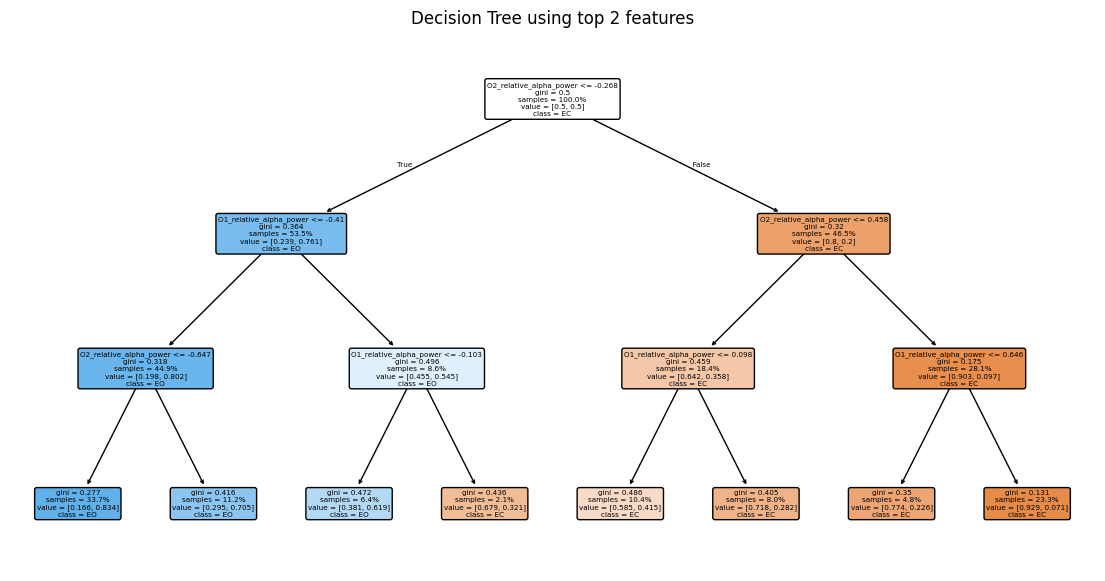

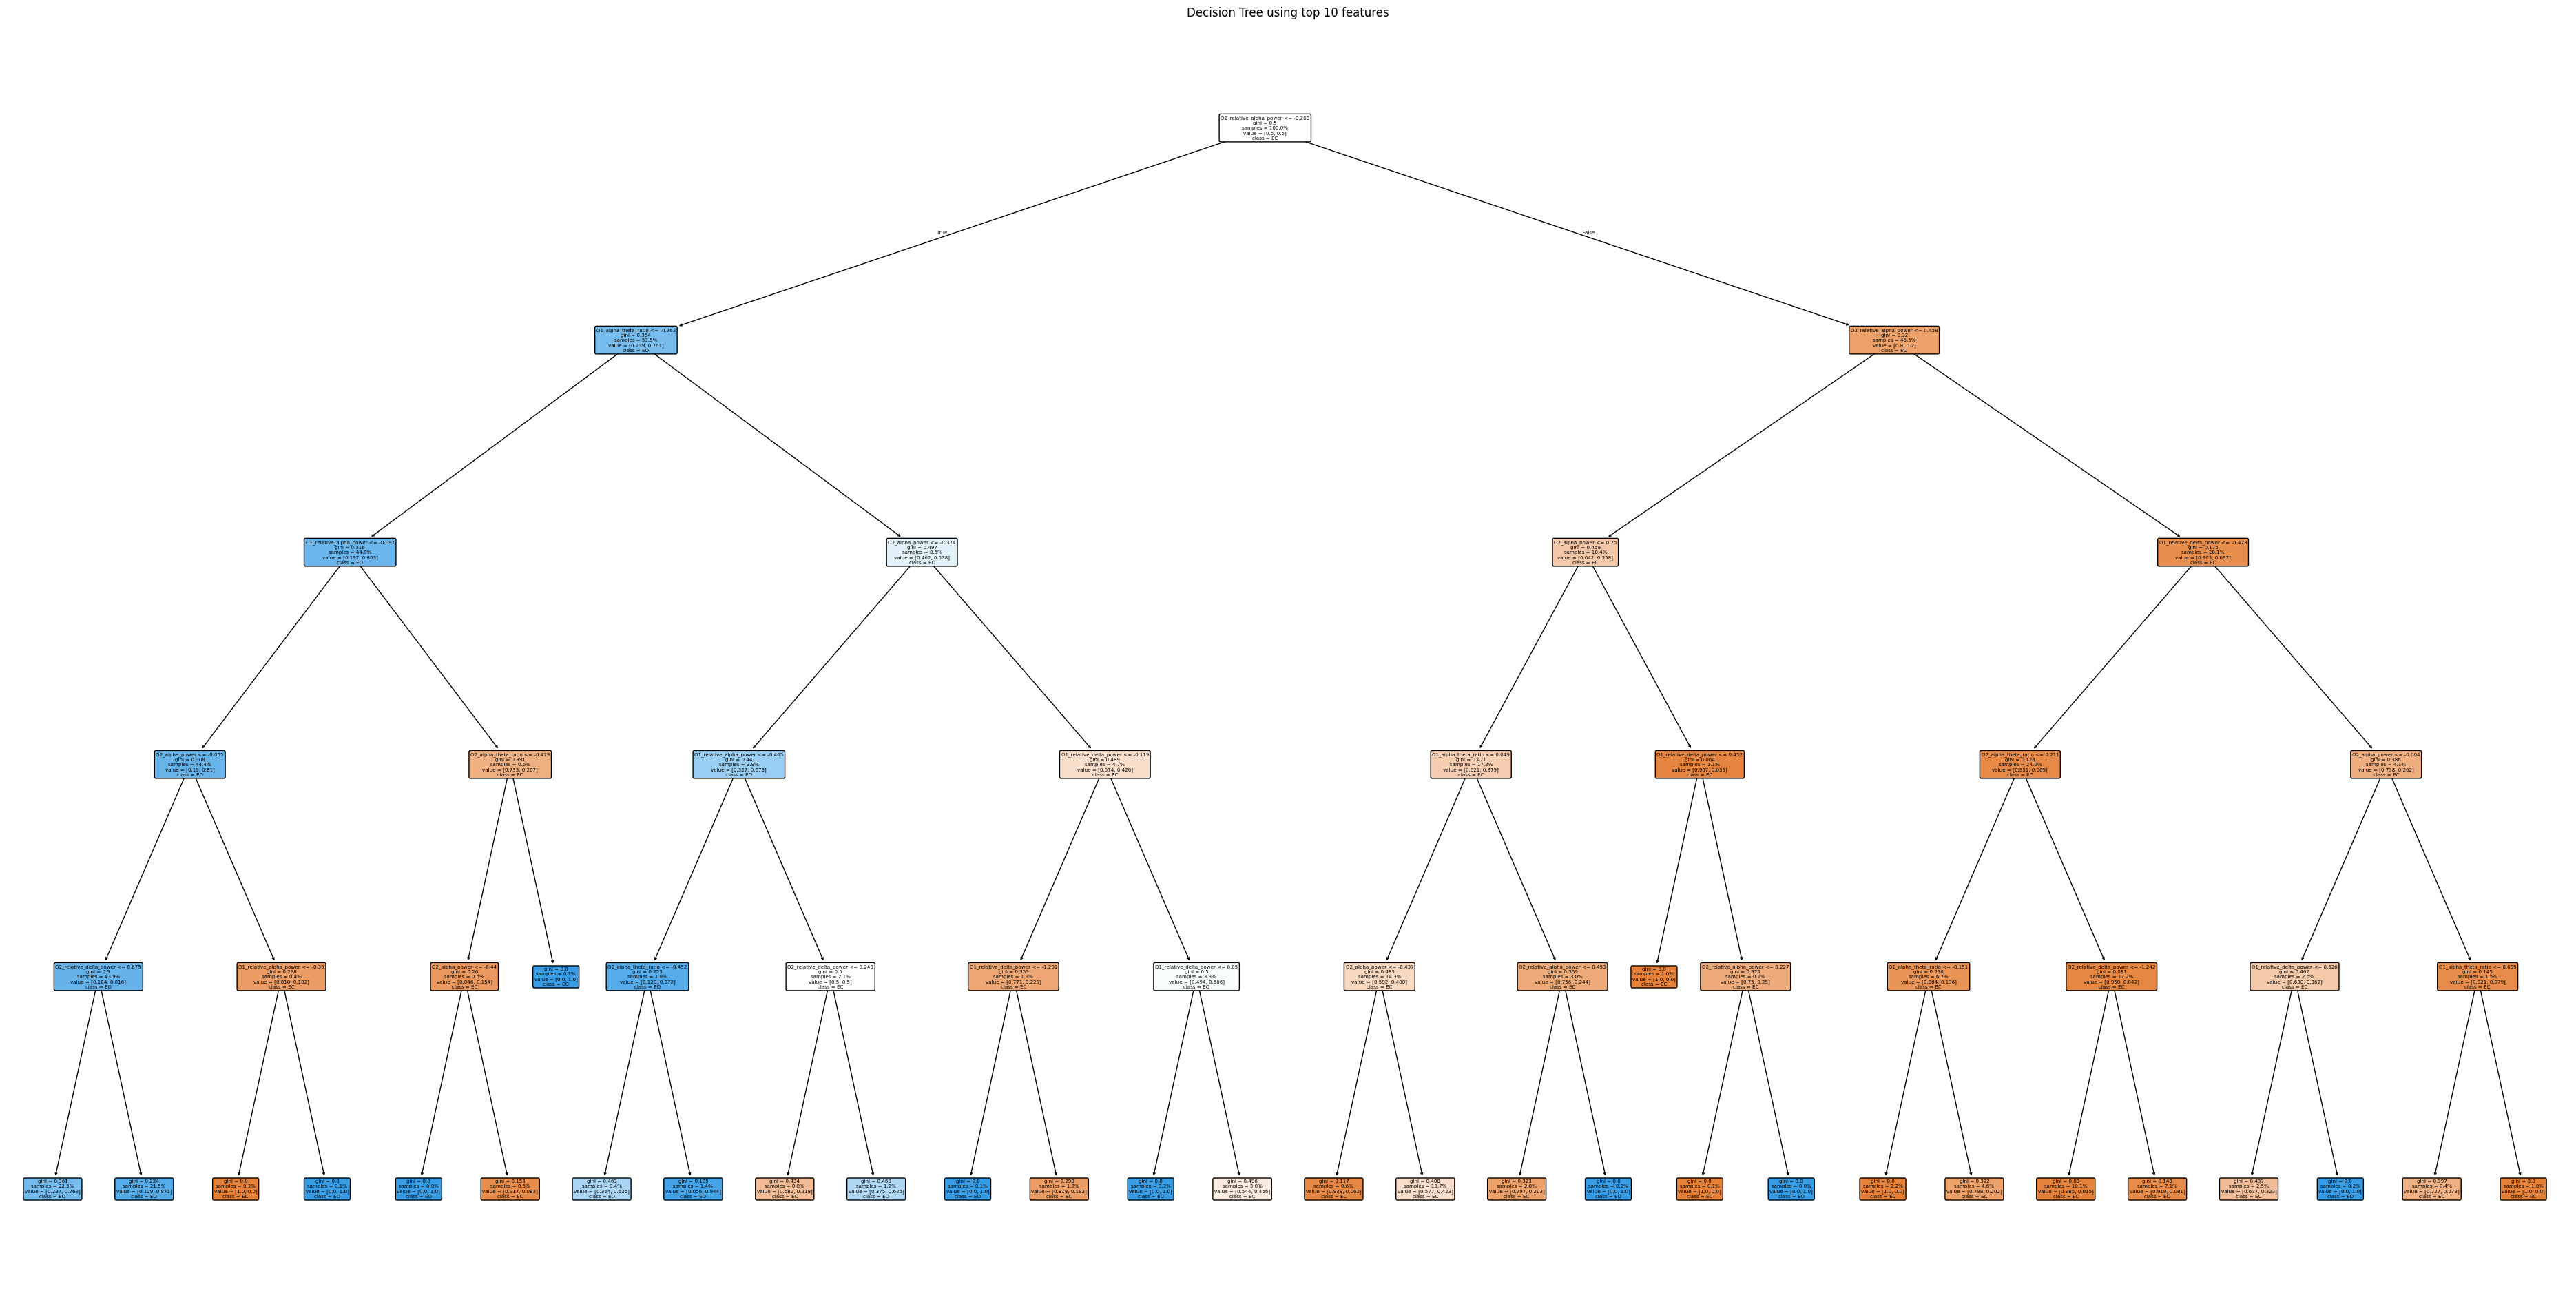

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

top2_features = [
    "O2_relative_alpha_power",
    "O1_relative_alpha_power",
]

top10_features = (
    ranking
    .sort_values("Average rank")   # or "Consensus rank"
    .head(10)["Feature"]
    .tolist()
)


dt_top2 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

dt_top2.fit(X_train[top2_features], y_train)


dt_top10 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_top10.fit(X_train[top10_features], y_train)

plt.figure(figsize=(14, 7))

plot_tree(
    dt_top2,
    feature_names=top2_features,
    class_names=dt_top2.classes_,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True
)

plt.title("Decision Tree using top 2 features")
plt.show()


plt.figure(figsize=(48, 24))

plot_tree(
    dt_top10,
    feature_names=top10_features,
    class_names=dt_top10.classes_,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True
)

plt.title("Decision Tree using top 10 features")
plt.show()

In [40]:
importance = pd.DataFrame({
    "Feature": top10_features,
    "Importance": dt_top10.feature_importances_
})

from collections import Counter

feature_names = np.array(top10_features)

used_features = feature_names[
    dt_top10.tree_.feature[dt_top10.tree_.feature >= 0]
]

usage = (
    pd.Series(Counter(used_features))
    .rename_axis("Feature")
    .reset_index(name="Splits")
)

tree_summary = (
    importance.merge(usage, on="Feature", how="left")
    .fillna({"Splits": 0})
)

tree_summary["Splits"] = tree_summary["Splits"].astype(int)

tree_summary = (
    tree_summary[tree_summary["Importance"] > 0]
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

tree_summary

,Feature,Importance,Splits
0,O2_relative_alpha_power,0.787415,4
1,O1_alpha_theta_ratio,0.059106,4
2,O2_alpha_power,0.054998,6
3,O1_relative_delta_power,0.037050,6
4,O1_relative_alpha_power,0.032932,3
5,O2_relative_delta_power,0.017528,3
6,O2_alpha_theta_ratio,0.010970,3


### 3.2. RIPPER
- using wittgenstein implementation

    - (note: wittgenstein implementation returns Boolean predictions (True/False) instead of the original class labels (T1/T2) and does not implement the estimator tags expected by utilities such as cross_val_predict()--> we define a lightweight wrapper that converts the Boolean predictions back to the corresponding class labels while exposing a standard classifier interface)

In [41]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import wittgenstein as lw
import numpy as np

class RipperWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pos_class="EC", random_state=42, max_rules=10, max_rule_conds=3):
        self.pos_class = pos_class
        self.random_state = random_state
        self.max_rules = max_rules
        self.max_rule_conds = max_rule_conds

    def fit(self, X, y):
        self.classes_ = np.unique(y)

        self.model_ = lw.RIPPER(
            random_state=self.random_state,
            max_rules=self.max_rules,
            max_rule_conds=self.max_rule_conds
        )

        self.model_.fit(
            X,
            y,
            pos_class=self.pos_class
        )

        return self

    def predict(self, X):
        pred = self.model_.predict(X)

        neg_class = [c for c in self.classes_ if c != self.pos_class][0]

        return np.where(pred, self.pos_class, neg_class)


X_ripper = features_df[top10_features]   # or selected_features
y = features_df["label"]
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_model = RipperWrapper(
    pos_class="EC",
    random_state=42,
    max_rules=10,
    max_rule_conds=3
)

y_pred_ripper = np.empty(len(y), dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_ripper, y, groups), start=1):
    model = clone(base_model)

    model.fit(X_ripper.iloc[train_idx], y.iloc[train_idx])
    y_pred_ripper[test_idx] = model.predict(X_ripper.iloc[test_idx])

    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
    print(f"Fold {fold}: subject overlap = {len(overlap)}")


print(f"Accuracy : {accuracy_score(y, y_pred_ripper):.3f}")
print(f"Precision: {precision_score(y, y_pred_ripper, pos_label='EC'):.3f}")
print(f"Recall   : {recall_score(y, y_pred_ripper, pos_label='EC'):.3f}")
print(f"F1-score : {f1_score(y, y_pred_ripper, pos_label='EC'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred_ripper))

Fold 1: subject overlap = 0
Fold 2: subject overlap = 0
Fold 3: subject overlap = 0
Fold 4: subject overlap = 0
Fold 5: subject overlap = 0
Accuracy : 0.700
Precision: 0.870
Recall   : 0.470
F1-score : 0.611

Classification report
              precision    recall  f1-score   support

          EC       0.87      0.47      0.61      1635
          EO       0.64      0.93      0.76      1635

    accuracy                           0.70      3270
   macro avg       0.75      0.70      0.68      3270
weighted avg       0.75      0.70      0.68      3270



#### LEARNED RULES

In [42]:
ripper_final = RipperWrapper(
    pos_class="EC",
    random_state=42,
    max_rules=10,
    max_rule_conds=3
)

X_final = features_df[top10_features]
y_final = features_df["label"]

ripper_final.fit(X_final, y_final)

print(ripper_final.model_.ruleset_)

[[O2_dominant_frequency=9.0-10.0^O2_alpha_power=>1631.43] V [O1_relative_alpha_power=0.52-0.68^O2_relative_delta_power=<0.094] V [O2_alpha_power=631.56-1631.43^O2_alpha_theta_ratio=>8.79] V [O2_relative_alpha_power=0.52-0.69^O2_dominant_frequency=10.0-10.5^O2_alpha_power=>1631.43] V [O2_relative_alpha_power=0.4-0.52^O1_relative_delta_power=0.15-0.2] V [O2_relative_alpha_power=0.52-0.69^O2_alpha_theta_ratio=4.64-8.79^O1_alpha_beta_ratio=2.22-3.58] V [O1_relative_delta_power=0.093-0.15^O1_alpha_beta_ratio=3.58-6.48] V [O1_relative_alpha_power=0.4-0.52^O2_alpha_power=631.56-1631.43^O2_relative_alpha_power=0.4-0.52] V [O2_alpha_power=340.6-631.56^O1_relative_alpha_power=0.52-0.68^O2_dominant_frequency=9.0-10.0]]


***Observation.** In contrast to the decision tree, RIPPER produces a considerably larger rule set while achieving lower classification performance (precision, recall). The continuous-valued EEG features must first be discretized into intervals, resulting in numerous interval-based rules that are difficult to interpret and less effective for this particular dataset.*

### 3.3. XGBoost

In [88]:
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import numpy as np

top20_features = (
    ranking
    .sort_values("Average rank")
    .head(20)["Feature"]
    .tolist()
)

X_xgb = features_df[top20_features]
y = features_df["label"]
y_bin = (y == "EC").astype(int)
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
)

y_pred_bin = np.empty(len(y_bin), dtype=int)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_xgb, y_bin, groups), start=1):
    model = clone(base_xgb)

    model.fit(
        X_xgb.iloc[train_idx],
        y_bin.iloc[train_idx]
    )

    y_pred_bin[test_idx] = model.predict(X_xgb.iloc[test_idx])


y_pred = np.where(y_pred_bin == 1, "EC", "EO")

print(f"Accuracy : {accuracy_score(y, y_pred):.3f}")
print(f"Precision: {precision_score(y, y_pred, pos_label='EC'):.3f}")
print(f"Recall   : {recall_score(y, y_pred, pos_label='EC'):.3f}")
print(f"F1-score : {f1_score(y, y_pred, pos_label='EC'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred))

print("\nConfusion matrix")
print(confusion_matrix(y, y_pred, labels=["EO", "EC"]))

Accuracy : 0.756
Precision: 0.777
Recall   : 0.718
F1-score : 0.746

Classification report
              precision    recall  f1-score   support

          EC       0.78      0.72      0.75      1635
          EO       0.74      0.79      0.76      1635

    accuracy                           0.76      3270
   macro avg       0.76      0.76      0.76      3270
weighted avg       0.76      0.76      0.76      3270


Confusion matrix
[[1298  337]
 [ 461 1174]]


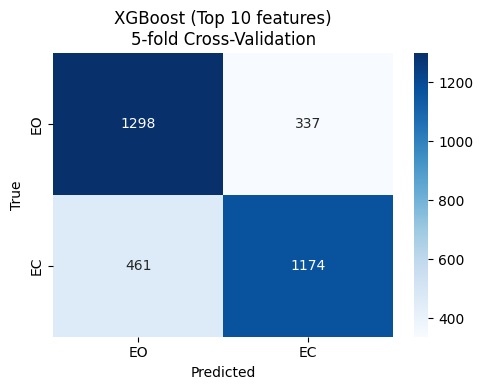

In [89]:
cm_xgb = confusion_matrix(y, y_pred, labels=["EO", "EC"])

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["EO", "EC"],
    yticklabels=["EO", "EC"],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost (Top 10 features)\n5-fold Cross-Validation")

plt.tight_layout()
plt.show()

#### XAI with Permutation Feature Importance (PFI)

- PFI - standard model-agnostic tool for eXplainable AI which provides post hoc explanation; tells us how much does performance drop when one feature is randomly shuffled

In [90]:
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import pandas as pd

X_pfi = features_df[top20_features]
y_pfi = (features_df["label"] == "EC").astype(int)

xgb_final = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
)

xgb_final.fit(X_pfi, y_pfi)

pfi = permutation_importance(
    xgb_final,
    X_pfi,
    y_pfi,
    scoring="f1",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

pfi_df = (
    pd.DataFrame({
        "Feature": X_pfi.columns,
        "PFI mean": pfi.importances_mean,
        "PFI std": pfi.importances_std,
    })
    .sort_values("PFI mean", ascending=False)
    .reset_index(drop=True)
)

pfi_df

,Feature,PFI mean,PFI std
0,O2_higuchi_fd,0.021807,0.002363
1,O1_lyapunov_exponent_long_tau,0.009952,0.000988
2,O1_higuchi_fd,0.008766,0.001386
3,O2_lyapunov_exponent_long_tau,0.007264,0.001382
4,O1_alpha_beta_ratio,0.005565,0.000722
5,O1_relative_theta_power,0.004912,0.001093
6,O1_std,0.004365,0.000774
7,O2_rms,0.003450,0.001006
8,O2_alpha_beta_ratio,0.003059,0.000499
9,O2_relative_theta_power,0.002953,0.000763


***Observation.** the more sophisticated XGBoost classifier did not outperform the decision tree, achieving a comparable accuracy of approximately 76%. Although XGBoost selected a different subset of features—including nonlinear measures such as Higuchi fractal dimension and Lyapunov exponent, as well as alpha-related and time-domain features—the overall classification performance remained essentially unchanged. This suggests that the eyes-open/eyes-closed discrimination is largely limited by the information contained in the selected features rather than by the choice of classifier, and that increasing model complexity provides little additional benefit.*

## 4. Analysis & interpretation

Accuracy: 0.759090909090909
F1-score: 0.7389162561576355


C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


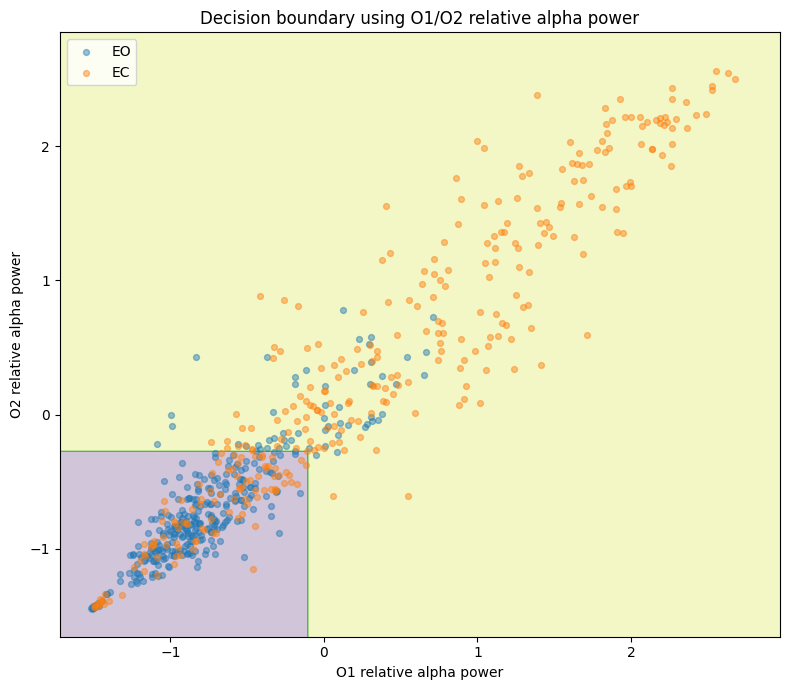

In [106]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# Top two alpha features
feat_x = "O1_relative_alpha_power"
feat_y = "O2_relative_alpha_power"

X2_train = X_train[[feat_x, feat_y]]
X2_test = X_test[[feat_x, feat_y]]

# Encode labels: EO = 0, EC = 1
y_train_num = (y_train == "EC").astype(int)
y_test_num = (y_test == "EC").astype(int)

# Train shallow DT (best model so far)
dt2 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt2.fit(X2_train, y_train_num)

y_pred = dt2.predict(X2_test)

print("Accuracy:", accuracy_score(y_test_num, y_pred))
print("F1-score:", f1_score(y_test_num, y_pred))


# Decision boundary grid
x_min, x_max = X2_train[feat_x].min(), X2_train[feat_x].max()
y_min, y_max = X2_train[feat_y].min(), X2_train[feat_y].max()

x_margin = 0.05 * (x_max - x_min)
y_margin = 0.05 * (y_max - y_min)

xx, yy = np.meshgrid(
    np.linspace(x_min - x_margin, x_max + x_margin, 400),
    np.linspace(y_min - y_margin, y_max + y_margin, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = dt2.predict(grid).reshape(xx.shape)


plt.figure(figsize=(8, 7))

# Background decision regions
plt.contourf(xx, yy, Z, alpha=0.25)

# Overlay test samples
plt.scatter(
    X2_test.loc[y_test == "EO", feat_x],
    X2_test.loc[y_test == "EO", feat_y],
    label="EO",
    alpha=0.45,
    s=18
)

plt.scatter(
    X2_test.loc[y_test == "EC", feat_x],
    X2_test.loc[y_test == "EC", feat_y],
    label="EC",
    alpha=0.45,
    s=18
)

plt.xlabel("O1 relative alpha power")
plt.ylabel("O2 relative alpha power")
plt.title("Decision boundary using O1/O2 relative alpha power")
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Test epochs in original order
epochs_test = epochs_df.loc[X_test.index].reset_index(drop=True)

# Predictions
y_pred = dt2.predict(X2_test)
y_true = y_test_num.values

correct = np.where(y_pred == y_true)[0]
fp = np.where((y_true == 0) & (y_pred == 1))[0]   # EO -> EC
fn = np.where((y_true == 1) & (y_pred == 0))[0]   # EC -> EO

In [108]:
def plot_psd(ax, signal, sfreq, label):
    f, p = welch(signal, fs=sfreq, nperseg=min(len(signal), 512))

    mask = (f >= 1) & (f <= 30)

    ax.plot(f[mask], p[mask], lw=2)
    ax.set_xlim(1, 30)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("PSD")
    ax.set_title(label)

    # highlight alpha band
    ax.axvspan(8, 13, alpha=0.15)

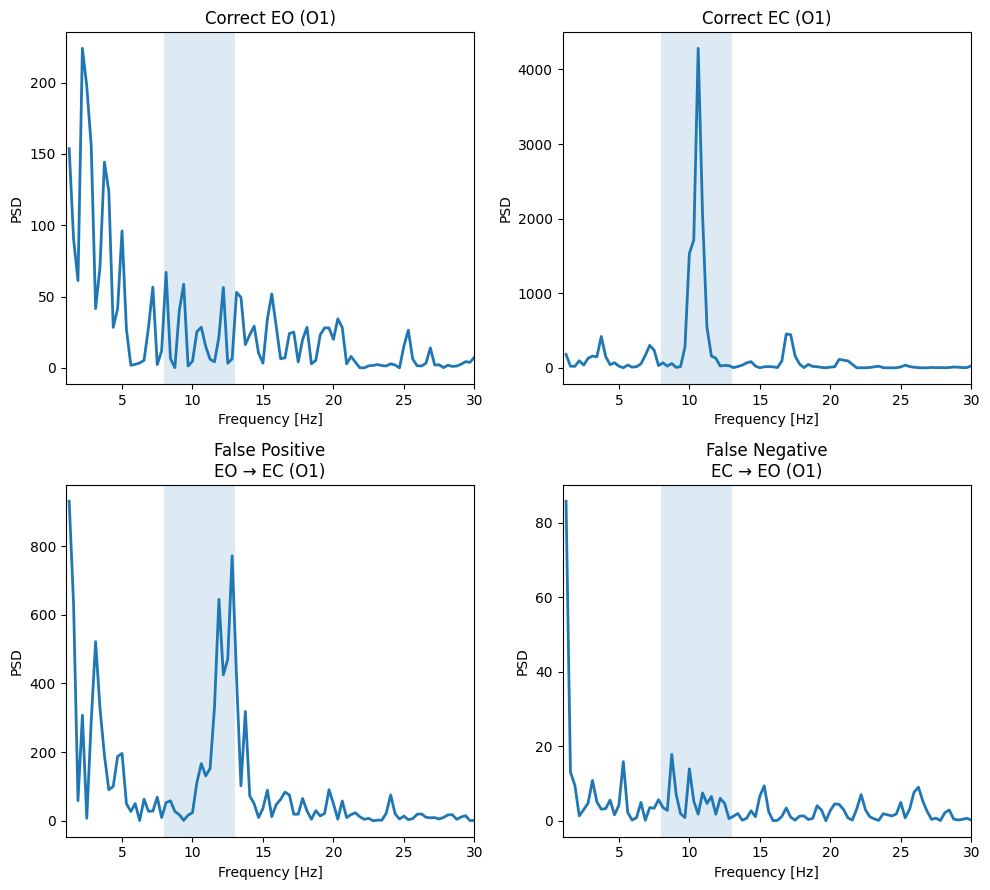

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

examples = [
    ("Correct EO", correct[np.where(y_true[correct] == 0)[0][0]]),
    ("Correct EC", correct[np.where(y_true[correct] == 1)[0][0]]),
    ("False Positive\nEO → EC", fp[0]),
    ("False Negative\nEC → EO", fn[0]),
]

for r, (title, idx) in enumerate(examples):

    row = epochs_test.iloc[idx]
    sf = row["sfreq"]

    plot_psd(
        axes[r//2, r%2],
        row["O1"],
        sf,
        title + " (O1)"
    )

plt.tight_layout()
plt.show()

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -------------------------------------------------------
# Predictions
# -------------------------------------------------------

y_pred = dt2.predict(X2_test)
y_true = y_test_num.values

epochs_test = epochs_df.loc[X_test.index].reset_index(drop=True)

correct_idx = np.where(y_pred == y_true)[0]

correct_EO = correct_idx[y_true[correct_idx] == 0]
correct_EC = correct_idx[y_true[correct_idx] == 1]

fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]   # EO predicted EC
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]   # EC predicted EO

print(f"Correct EO: {len(correct_EO)}")
print(f"Correct EC: {len(correct_EC)}")
print(f"False Positive: {len(fp_idx)}")
print(f"False Negative: {len(fn_idx)}")

rng = np.random.default_rng(42)

n = min(
    len(correct_EO),
    len(correct_EC),
    len(fp_idx),
    len(fn_idx),
    200,          # cap so the plot is fast
)

correct_EO = rng.choice(correct_EO, n, replace=False)
correct_EC = rng.choice(correct_EC, n, replace=False)
fp_idx = rng.choice(fp_idx, n, replace=False)
fn_idx = rng.choice(fn_idx, n, replace=False)

print(f"Using {n} epochs per group.")

def mean_psd(indices, channel="O1"):

    psds = []

    for idx in indices:
        row = epochs_test.iloc[idx]

        f, p = welch(
            row[channel],
            fs=row["sfreq"],
            nperseg=min(512, len(row[channel]))
        )

        mask = (f >= 1) & (f <= 30)

        psds.append(p[mask])

    return f[mask], np.mean(psds, axis=0)

Correct EO: 276
Correct EC: 225
False Positive: 54
False Negative: 105
Using 54 epochs per group.


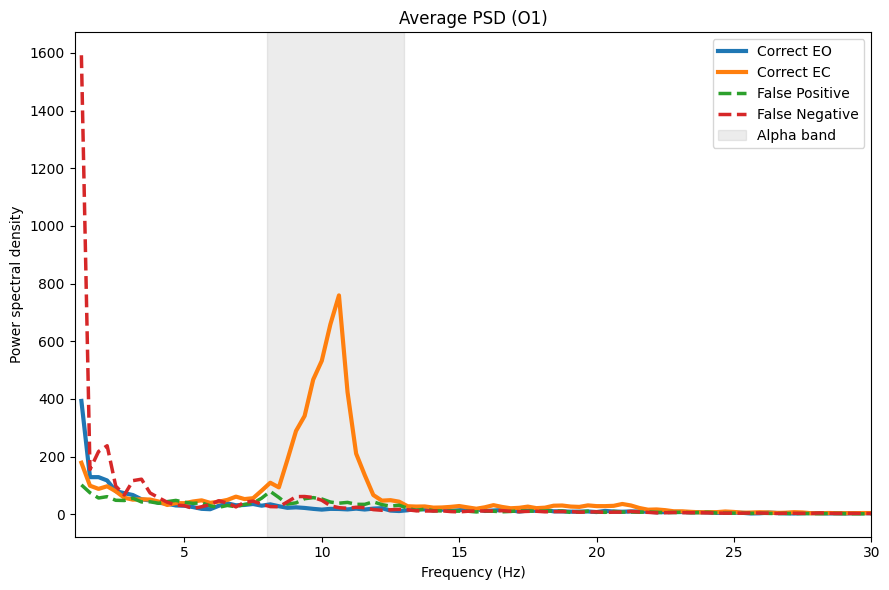

In [124]:
channel = "O1"


f, psd_correct_EO = mean_psd(correct_EO, channel)
_, psd_correct_EC = mean_psd(correct_EC, channel)
_, psd_fp = mean_psd(fp_idx, channel)
_, psd_fn = mean_psd(fn_idx, channel)

plt.figure(figsize=(9,6))

plt.plot(f, psd_correct_EO, lw=3, label="Correct EO")
plt.plot(f, psd_correct_EC, lw=3, label="Correct EC")
plt.plot(f, psd_fp, "--", lw=2.5, label="False Positive")
plt.plot(f, psd_fn, "--", lw=2.5, label="False Negative")

plt.axvspan(8, 13, color="gray", alpha=0.15, label="Alpha band")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title(f"Average PSD ({channel})")
plt.xlim(1,30)
plt.legend()

plt.tight_layout()
plt.show()

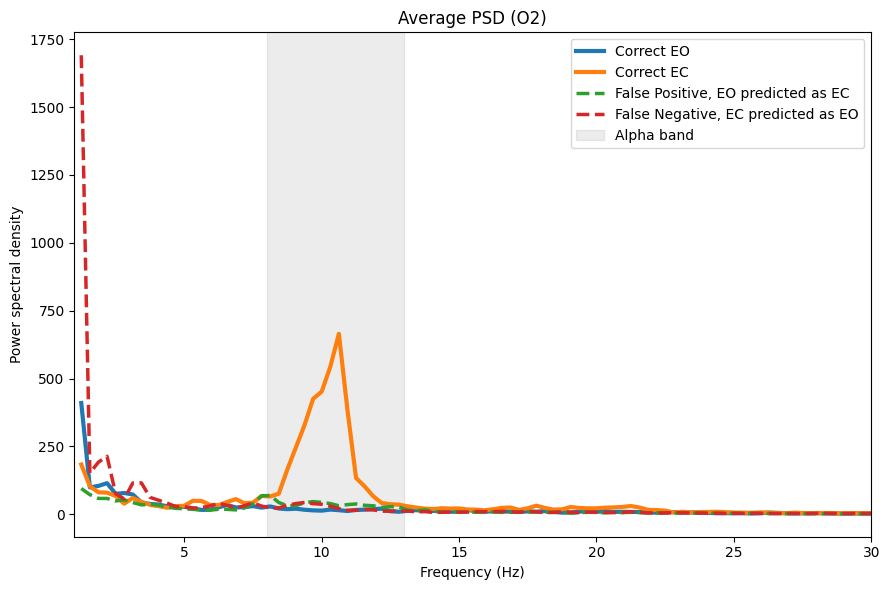

In [119]:
channel = "O2"

f, psd_correct_EO = mean_psd(correct_EO, channel)
_, psd_correct_EC = mean_psd(correct_EC, channel)
_, psd_fp = mean_psd(fp_idx, channel)
_, psd_fn = mean_psd(fn_idx, channel)

plt.figure(figsize=(9,6))

plt.plot(f, psd_correct_EO, lw=3, label="Correct EO")
plt.plot(f, psd_correct_EC, lw=3, label="Correct EC")
plt.plot(f, psd_fp, "--", lw=2.5, label="False Positive, EO predicted as EC")
plt.plot(f, psd_fn, "--", lw=2.5, label="False Negative, EC predicted as EO")

plt.axvspan(8, 13, color="gray", alpha=0.15, label="Alpha band")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title(f"Average PSD ({channel})")
plt.xlim(1,30)
plt.legend()

plt.tight_layout()
plt.show()